# Applied Methods of Analysis II: Final Project
Name: Jonas Nepozitek \
Date: x

In [1]:
import pandas as pd
import wbgapi as wb
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np

from stargazer.stargazer import Stargazer
from IPython.display import display, HTML
from statsmodels.nonparametric.smoothers_lowess import lowess

## Part III. Data Description

In [2]:
# EU and Eurozone countries for 2007
eu = [
    'AUT',  # Austria
    'BEL',  # Belgium
    'BGR',  # Bulgaria
    'CYP',  # Cyprus
    'CZE',  # Czech Republic
    'DNK',  # Denmark
    'EST',  # Estonia
    'FIN',  # Finland
    'FRA',  # France
    'DEU',  # Germany
    'GRC',  # Greece
    'HUN',  # Hungary
    'IRL',  # Ireland
    'ITA',  # Italy
    'LVA',  # Latvia
    'LTU',  # Lithuania
    'LUX',  # Luxembourg
    'MLT',  # Malta
    'NLD',  # Netherlands
    'POL',  # Poland
    'PRT',  # Portugal
    'ROU',  # Romania
    'SVK',  # Slovakia
    'SVN',  # Slovenia
    'ESP',  # Spain
    'SWE',  # Sweden
    'GBR',  # United Kingdom
]

eurozone = [
    'AUT', 'BEL', 'FIN', 'FRA', 
    'DEU', 'GRC', 'IRL', 'ITA',
    'LUX', 'NLD', 'PRT', 'SVN',
    'ESP'
]

# WB data
gdp = wb.data.DataFrame('NY.GDP.PCAP.PP.CD', time=range(2008, 2010))
gdp = gdp[gdp.index.isin(eu)]

unemployment = wb.data.DataFrame('SL.UEM.TOTL.ZS', time=range(2008, 2010))
unemployment = unemployment[unemployment.index.isin(eu)]

manufacturing = wb.data.DataFrame('NV.IND.MANF.ZS', time=2007)
manufacturing = manufacturing[manufacturing.index.isin(eu)]

credit = wb.data.DataFrame('FS.AST.PRVT.GD.ZS', time=2007)
credit = credit[credit.index.isin(eu)]

lending = wb.data.DataFrame('GC.NLD.TOTL.GD.ZS', time=2007)
lending = lending[lending.index.isin(eu)]

trade = wb.data.DataFrame('NE.TRD.GNFS.ZS', time=2007)
trade = trade[trade.index.isin(eu)]

# WGI data
wgi = pd.read_excel('inputs/Raw Data from Underlying Data Sources (1996-2024).xlsx', sheet_name='GE')

wgi = (
    wgi[
        (wgi['indicator'] == 'average of all ge indicators')
        & (wgi['econ_code'].isin(eu))
        & (wgi['production_year'] == 2007)
    ]
    [['econ_code', 'production_year', 'value']]
    .groupby(['econ_code', 'production_year'])['value']
    .mean()
    .reset_index()
    .pivot(index='econ_code', columns='production_year', values='value')
)

In [3]:
manufacturing = manufacturing.rename(columns={manufacturing.columns[0]: 'manufacturing'})
credit = credit.rename(columns={credit.columns[0]: 'credit'})
lending = lending.rename(columns={lending.columns[0]: 'lending'})
trade = trade.rename(columns={trade.columns[0]: 'trade'})
wgi = wgi.rename(columns={wgi.columns[0]: 'wgi'})

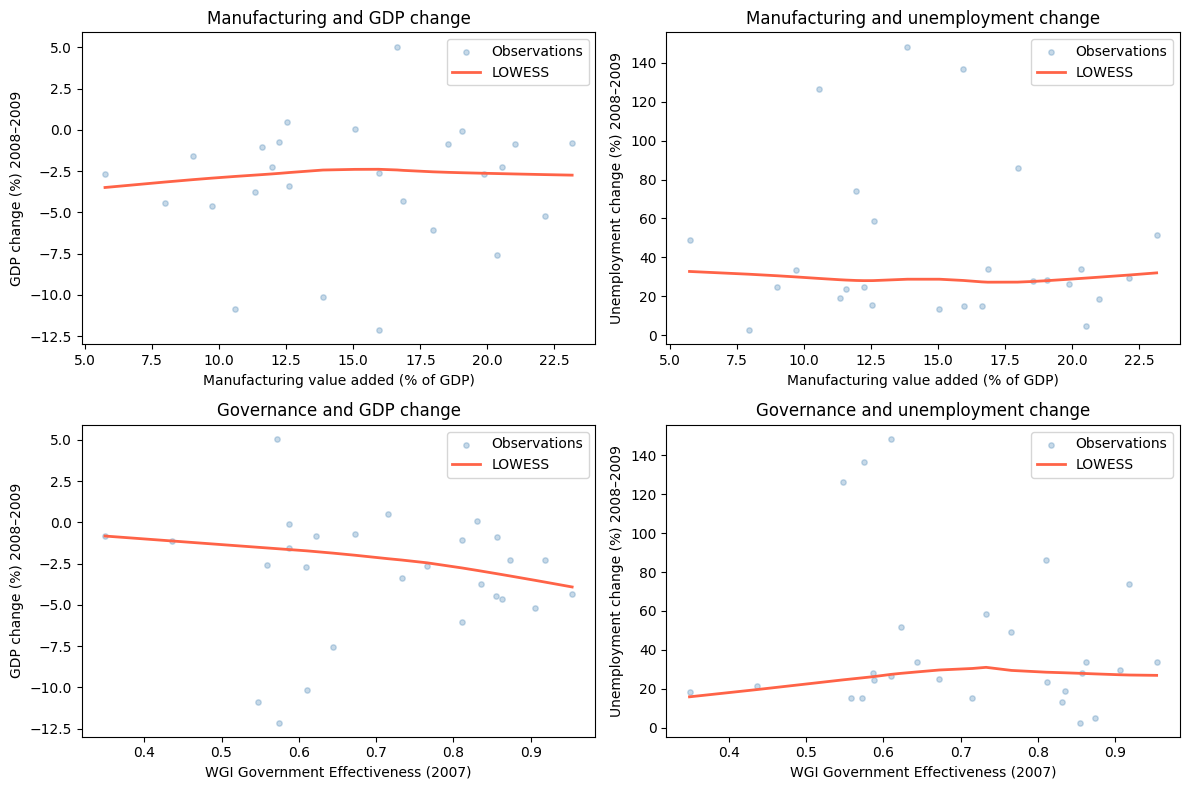

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

# 1) Manuf vs GDP change
gdp_change = (gdp["YR2009"] - gdp["YR2008"]) / gdp["YR2008"] * 100
sm = lowess(gdp_change, manufacturing["manufacturing"], frac=0.9)

ax = axes[0]
ax.scatter(manufacturing["manufacturing"], gdp_change, alpha=0.3, s=15,
           color='steelblue', label='Observations')
ax.plot(sm[:, 0], sm[:, 1], color='tomato', linewidth=2, label='LOWESS')
ax.set_xlabel('Manufacturing value added (% of GDP)')
ax.set_ylabel('GDP change (%) 2008–2009')
ax.set_title('Manufacturing and GDP change')
ax.legend()

# 2) Manuf vs Unemployment change
unemp_change = (unemployment["YR2009"] - unemployment["YR2008"]) / unemployment["YR2008"] * 100
sm = lowess(unemp_change, manufacturing["manufacturing"], frac=0.9)

ax = axes[1]
ax.scatter(manufacturing["manufacturing"], unemp_change, alpha=0.3, s=15,
           color='steelblue', label='Observations')
ax.plot(sm[:, 0], sm[:, 1], color='tomato', linewidth=2, label='LOWESS')
ax.set_xlabel('Manufacturing value added (% of GDP)')
ax.set_ylabel('Unemployment change (%) 2008–2009')
ax.set_title('Manufacturing and unemployment change')
ax.legend()

# 3) WGI vs GDP change
sm = lowess(gdp_change, wgi["wgi"], frac=0.9)

ax = axes[2]
ax.scatter(wgi["wgi"], gdp_change, alpha=0.3, s=15,
           color='steelblue', label='Observations')
ax.plot(sm[:, 0], sm[:, 1], color='tomato', linewidth=2, label='LOWESS')
ax.set_xlabel('WGI Government Effectiveness (2007)')
ax.set_ylabel('GDP change (%) 2008–2009')
ax.set_title('Governance and GDP change')
ax.legend()

# 4) WGI vs Unemployment change
sm = lowess(unemp_change, wgi["wgi"], frac=0.9)

ax = axes[3]
ax.scatter(wgi["wgi"], unemp_change, alpha=0.3, s=15,
           color='steelblue', label='Observations')
ax.plot(sm[:, 0], sm[:, 1], color='tomato', linewidth=2, label='LOWESS')
ax.set_xlabel('WGI Government Effectiveness (2007)')
ax.set_ylabel('Unemployment change (%) 2008–2009')
ax.set_title('Governance and unemployment change')
ax.legend()

plt.tight_layout()
plt.savefig("outputs/data_description.png", dpi=300, bbox_inches="tight")
plt.show()

## Part V. Key Results

In [5]:
gdp_changes = gdp[["YR2008", "YR2009"]].copy()
gdp_changes["gdp_change"] = gdp_changes["YR2009"] - gdp_changes["YR2008"]
gdp_changes["gdp_change_log"] = np.log(gdp_changes["YR2009"] / gdp_changes["YR2008"])
gdp_changes = gdp_changes[["gdp_change", "gdp_change_log"]]

unemp_changes = unemployment[["YR2008", "YR2009"]].copy()
unemp_changes["unemployment_change"] = unemp_changes["YR2009"] - unemp_changes["YR2008"]
unemp_changes["unemployment_change_log"] = np.log(unemp_changes["YR2009"] / unemp_changes["YR2008"])
unemp_changes = unemp_changes[["unemployment_change", "unemployment_change_log"]]

manuf_cov = manufacturing.copy()
cred_cov = credit.copy()
lend_cov = lending.copy()
trade_cov = trade.copy()
gov_cov = wgi.copy()

reg_data = (
    pd.concat(
        [gdp_changes, unemp_changes, manuf_cov, cred_cov, lend_cov, trade_cov, gov_cov],
        axis=1
    )
).dropna()

reg_data["eurozone"] = reg_data.index.isin(eurozone).astype(int)

print("Final sample after dropping NaN:", reg_data.shape[0])
print("Countries:", list(reg_data.index))
reg_data.head()

Final sample after dropping NaN: 24
Countries: ['AUT', 'BEL', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HUN', 'IRL', 'ITA', 'LUX', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']


,gdp_change,gdp_change_log,unemployment_change,unemployment_change_log,manufacturing,credit,lending,trade,wgi,eurozone
AUT,-360.116400,-0.008812,1.173,0.246406,18.548721,93.502589,-1.197757,101.364958,0.856818,1
BEL,22.326371,0.000589,0.932,0.125399,15.060318,68.443849,-0.445930,152.468447,0.830771,1
CYP,-928.765625,-0.027028,1.838,0.398340,5.742786,180.680730,3.342936,111.275123,0.765818,0
CZE,-224.598112,-0.008072,2.270,0.416635,23.158567,38.711139,-0.959620,129.876740,0.622664,0
DEU,-869.547614,-0.022879,0.372,0.048359,20.529891,95.498344,-0.168868,74.883842,0.873369,1


In [6]:
# Extended horizon: 2008–2013
gdp_long = wb.data.DataFrame('NY.GDP.PCAP.PP.CD', time=range(2008, 2014))
gdp_long = gdp_long[gdp_long.index.isin(eu)]

unemp_long = wb.data.DataFrame('SL.UEM.TOTL.ZS', time=range(2008, 2014))
unemp_long = unemp_long[unemp_long.index.isin(eu)]

gdp_long_changes = pd.DataFrame(index=gdp_long.index)
gdp_long_changes["gdp_change_log_long"] = np.log(gdp_long["YR2013"] / gdp_long["YR2008"])

unemp_long_changes = pd.DataFrame(index=unemp_long.index)
unemp_long_changes["unemployment_change_log_long"] = np.log(unemp_long["YR2013"] / unemp_long["YR2008"])

reg_data_long = (
    pd.concat(
        [gdp_long_changes, unemp_long_changes, manuf_cov, cred_cov, lend_cov, trade_cov, gov_cov],
        axis=1
    )
).dropna()

reg_data_long["eurozone"] = reg_data_long.index.isin(eurozone).astype(int)

print("Extended horizon sample:", reg_data_long.shape[0])
print("Countries:", list(reg_data_long.index))
reg_data_long.head()

Extended horizon sample: 24
Countries: ['AUT', 'BEL', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HUN', 'IRL', 'ITA', 'LUX', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']


,gdp_change_log_long,unemployment_change_log_long,manufacturing,credit,lending,trade,wgi,eurozone
AUT,0.146435,0.245661,18.548721,93.502589,-1.197757,101.364958,0.856818,1
BEL,0.146585,0.188728,15.060318,68.443849,-0.445930,152.468447,0.830771,1
CYP,-0.135520,1.457388,5.742786,180.680730,3.342936,111.275123,0.765818,0
CZE,0.104425,0.459389,23.158567,38.711139,-0.959620,129.876740,0.622664,0
DEU,0.177035,-0.345248,20.529891,95.498344,-0.168868,74.883842,0.873369,1


In [7]:
gdp_m1 = smf.ols(
    "gdp_change_log ~ manufacturing",
    data=reg_data
).fit(cov_type="HC3")

gdp_m2 = smf.ols(
    "gdp_change_log ~ wgi",
    data=reg_data
).fit(cov_type="HC3")

gdp_m3 = smf.ols(
    "gdp_change_log ~ manufacturing + wgi + credit + lending + trade",
    data=reg_data
).fit(cov_type="HC3")

gdp_m4 = smf.ols(
    "gdp_change_log ~ manufacturing + wgi + credit + lending + trade + eurozone",
    data=reg_data
).fit(cov_type="HC3")

gdp_m5 = smf.ols(
    "gdp_change_log ~ manufacturing * wgi + credit + lending + trade + eurozone",
    data=reg_data
).fit(cov_type="HC3")

gdp_stargazer = Stargazer([gdp_m1, gdp_m2, gdp_m3, gdp_m4, gdp_m5])
gdp_stargazer.title("Regression results: GDP per capita (log change 2008–2009)")
gdp_stargazer.custom_columns(
    ["Model 1 (manufacturing only)",
     "Model 2 (wgi only)",
     "Model 3 (+financial)",
     "Model 4 (+Eurozone dummy)",
     "Model 5 (+interaction term)"],
    [1, 1, 1, 1, 1]
)
gdp_stargazer.show_degrees_of_freedom(False)
gdp_stargazer.covariate_order([
    "manufacturing", "wgi", "manufacturing:wgi",
    "credit", "lending", "trade", "eurozone", "Intercept"
])

display(HTML(gdp_stargazer.render_html()))

In [8]:
unemp_m1 = smf.ols(
    "unemployment_change_log ~ manufacturing",
    data=reg_data
).fit(cov_type="HC3")

unemp_m2 = smf.ols(
    "unemployment_change_log ~ wgi",
    data=reg_data
).fit(cov_type="HC3")

unemp_m3 = smf.ols(
    "unemployment_change_log ~ manufacturing + wgi + credit + lending + trade",
    data=reg_data
).fit(cov_type="HC3")

unemp_m4 = smf.ols(
    "unemployment_change_log ~ manufacturing + wgi + credit + lending + trade + eurozone",
    data=reg_data
).fit(cov_type="HC3")

unemp_m5 = smf.ols(
    "unemployment_change_log ~ manufacturing * wgi + credit + lending + trade + eurozone",
    data=reg_data
).fit(cov_type="HC3")

unemp_stargazer = Stargazer([unemp_m1, unemp_m2, unemp_m3, unemp_m4, unemp_m5])
unemp_stargazer.title("Regression results: Unemployment (log change 2008–2009)")
unemp_stargazer.custom_columns(
    ["Model 1 (manufacturing only)",
     "Model 2 (wgi only)",
     "Model 3 (+financial)",
     "Model 4 (+Eurozone dummy)",
     "Model 5 (+interaction term)"],
    [1, 1, 1, 1, 1]
)
unemp_stargazer.show_degrees_of_freedom(False)
unemp_stargazer.covariate_order([
    "manufacturing", "wgi", "manufacturing:wgi",
    "credit", "lending", "trade", "eurozone", "Intercept"
])

display(HTML(unemp_stargazer.render_html()))

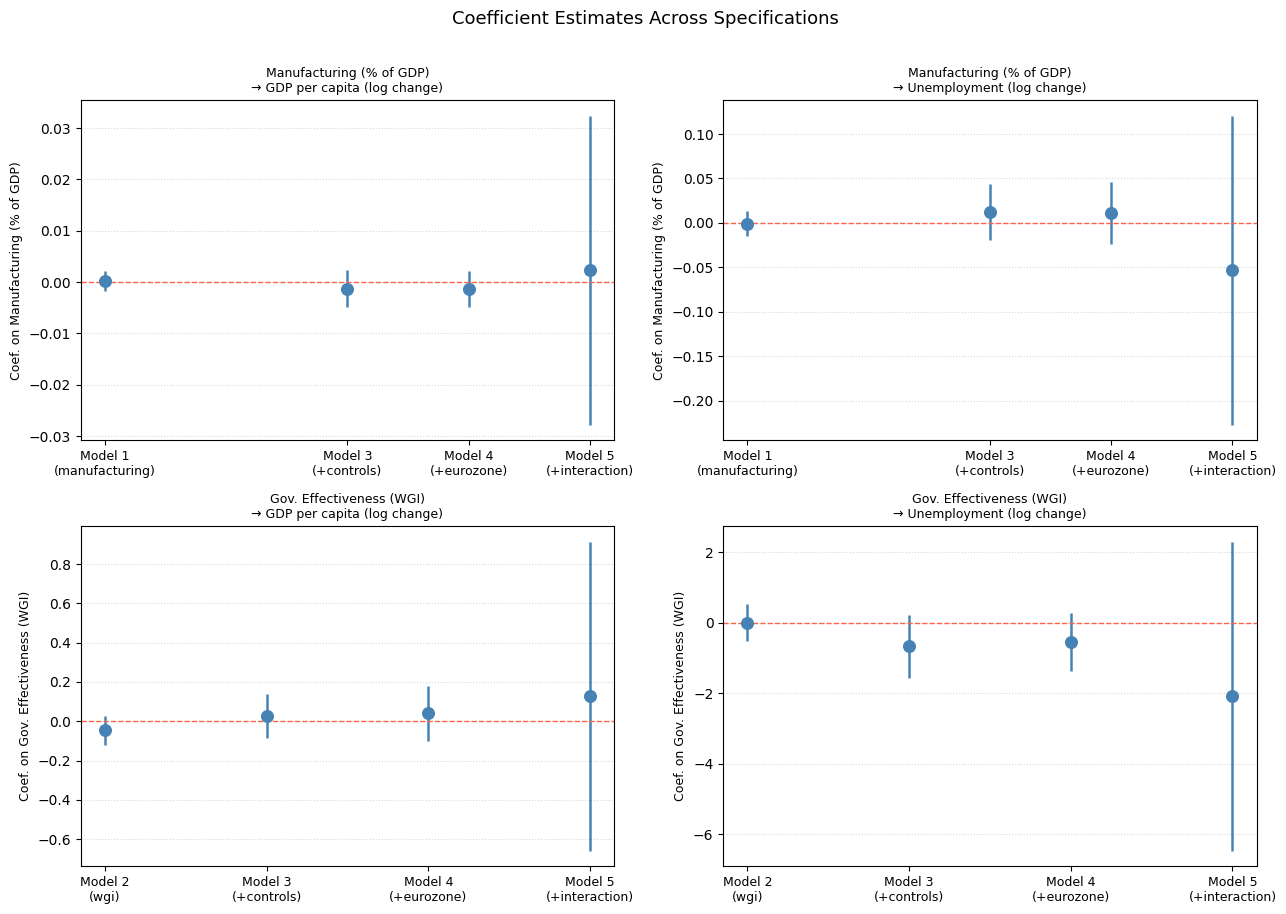

In [9]:
models_gdp   = [gdp_m1, gdp_m2, gdp_m3, gdp_m4, gdp_m5]
models_unemp = [unemp_m1, unemp_m2, unemp_m3, unemp_m4, unemp_m5]
labels = ["Model 1\n(manufacturing)", "Model 2\n(wgi)", 
          "Model 3\n(+controls)", "Model 4\n(+eurozone)", "Model 5\n(+interaction)"]

def get_coef(model, var):
    if var in model.params:
        return model.params[var], model.conf_int().loc[var]
    return None, None

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Coefficient Estimates Across Specifications", fontsize=13, y=1.01)

plot_config = [
    # (row, col, variable, outcome models, outcome label)
    (0, 0, "manufacturing", models_gdp,   "GDP per capita (log change)"),
    (0, 1, "manufacturing", models_unemp, "Unemployment (log change)"),
    (1, 0, "wgi",           models_gdp,   "GDP per capita (log change)"),
    (1, 1, "wgi",           models_unemp, "Unemployment (log change)"),
]

var_labels = {
    "manufacturing": "Manufacturing (% of GDP)",
    "wgi":           "Gov. Effectiveness (WGI)"
}

for row, col, var, models, outcome_title in plot_config:
    ax = axes[row, col]
    x_positions = []
    coefs, lows, highs, tick_labels = [], [], [], []

    for i, (m, lbl) in enumerate(zip(models, labels)):
        coef, ci = get_coef(m, var)
        if coef is not None:
            x_positions.append(i)
            coefs.append(coef)
            lows.append(ci[0])
            highs.append(ci[1])
            tick_labels.append(lbl)

    ax.scatter(x_positions, coefs, color="steelblue", zorder=3, s=70)
    ax.vlines(x_positions, lows, highs, color="steelblue", linewidth=1.8)
    ax.axhline(0, color="tomato", linestyle="--", linewidth=1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_ylabel(f"Coef. on {var_labels[var]}", fontsize=9)
    ax.set_title(f"{var_labels[var]}\n→ {outcome_title}", fontsize=9)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("outputs/coefficient_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# GDP 2008-2013 regressions
gdp_long_m1 = smf.ols("gdp_change_log_long ~ manufacturing", data=reg_data_long).fit(cov_type="HC3")
gdp_long_m2 = smf.ols("gdp_change_log_long ~ wgi", data=reg_data_long).fit(cov_type="HC3")
gdp_long_m3 = smf.ols("gdp_change_log_long ~ manufacturing + wgi + credit + lending + trade", data=reg_data_long).fit(cov_type="HC3")
gdp_long_m4 = smf.ols("gdp_change_log_long ~ manufacturing + wgi + credit + lending + trade + eurozone", data=reg_data_long).fit(cov_type="HC3")
gdp_long_m5 = smf.ols("gdp_change_log_long ~ manufacturing * wgi + credit + lending + trade + eurozone", data=reg_data_long).fit(cov_type="HC3")

gdp_long_stargazer = Stargazer([gdp_long_m1, gdp_long_m2, gdp_long_m3, gdp_long_m4, gdp_long_m5])
gdp_long_stargazer.title("Regression results: GDP per capita (log change 2008–2013)")
gdp_long_stargazer.custom_columns(
    ["Model 1 (manufacturing only)", "Model 2 (wgi only)", "Model 3 (+financial)",
     "Model 4 (+Eurozone dummy)", "Model 5 (+interaction term)"], [1, 1, 1, 1, 1]
)
gdp_long_stargazer.show_degrees_of_freedom(False)
gdp_long_stargazer.covariate_order([
    "manufacturing", "wgi", "manufacturing:wgi",
    "credit", "lending", "trade", "eurozone", "Intercept"
])
display(HTML(gdp_long_stargazer.render_html()))

In [12]:
# Unemployment 2008-2013 regressions
unemp_long_m1 = smf.ols("unemployment_change_log_long ~ manufacturing", data=reg_data_long).fit(cov_type="HC3")
unemp_long_m2 = smf.ols("unemployment_change_log_long ~ wgi", data=reg_data_long).fit(cov_type="HC3")
unemp_long_m3 = smf.ols("unemployment_change_log_long ~ manufacturing + wgi + credit + lending + trade", data=reg_data_long).fit(cov_type="HC3")
unemp_long_m4 = smf.ols("unemployment_change_log_long ~ manufacturing + wgi + credit + lending + trade + eurozone", data=reg_data_long).fit(cov_type="HC3")
unemp_long_m5 = smf.ols("unemployment_change_log_long ~ manufacturing * wgi + credit + lending + trade + eurozone", data=reg_data_long).fit(cov_type="HC3")

unemp_long_stargazer = Stargazer([unemp_long_m1, unemp_long_m2, unemp_long_m3, unemp_long_m4, unemp_long_m5])
unemp_long_stargazer.title("Regression results: Unemployment (log change 2008–2013)")
unemp_long_stargazer.custom_columns(
    ["Model 1 (manufacturing only)", "Model 2 (wgi only)", "Model 3 (+financial)",
     "Model 4 (+Eurozone dummy)", "Model 5 (+interaction term)"], [1, 1, 1, 1, 1]
)
unemp_long_stargazer.show_degrees_of_freedom(False)
unemp_long_stargazer.covariate_order([
    "manufacturing", "wgi", "manufacturing:wgi",
    "credit", "lending", "trade", "eurozone", "Intercept"
])
display(HTML(unemp_long_stargazer.render_html()))